In [1]:
import torch
from pathlib import Path
import matplotlib.pyplot as plt
from torch_geometric.nn import to_hetero
from torch_geometric.loader import DataLoader

from halide_gnn_cost_model.data import PipelineDataset, PipelineDatasetTransformer, get_ast_vocab_size, get_sched_vocab_size
from halide_gnn_cost_model.model import PipeGCN, PipeGAT, PipelineModel, PipeGPS

In [2]:
PIPELINES_DIR = Path("/lscratch/fzhou48/pipelines-test")
GCN_MODEL_PATH = Path("/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/resources/models/gcn/pipeline_model_epoch_400.pt")
GAT_MODEL_PATH = Path("/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/resources/models/gat-h64-o64-l4-hd8-mh32-v2/pipeline_model_epoch_160.pt")
GRAPH_TRANSFORMER_MODEL_PATH = Path("/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/resources/models/graph_transformer-h128-l8-h8/pipeline_model_epoch_100.pt")

In [3]:
USE_GPU = True

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
elif USE_GPU and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
# Load dataset
dataset = PipelineDataset(PIPELINES_DIR)
data = dataset[0]  # Get the first pipeline graph
len(dataset)

1lines [00:00, 6732.43lines/s]
1lines [00:00, 27235.74lines/s]


2157

In [5]:
dataset_transformer = PipelineDatasetTransformer(PIPELINES_DIR)
data_transformer = dataset_transformer[0]
len(dataset_transformer)

2157

In [6]:
data_loader = DataLoader(dataset, batch_size=64, shuffle=False)
data_loader_transformer = DataLoader(dataset_transformer, batch_size=64, shuffle=False)

# Eval Metrics

In [7]:
def average_runtime_error(model, data_loader):
    model.eval()
    total_error = 0
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            pred_log = model(batch, batch["loop_level"].ptr)
            pred = torch.exp(pred_log).reshape(-1)
            true = batch.y
            error = torch.abs(pred - true) / true
            total_error += error.mean().item()
    return total_error / len(data_loader)

In [8]:
def average_runtime_error_transformer(model, data_loader):
    model.eval()
    total_error = 0
    with torch.no_grad():
        for data in data_loader:
            data = data.to(device)
            x = data.type
            edge_index = data.edge_index
            pe = torch.cat((data.laplacian_eigenvector_pe, data.random_walk_pe, data.degree_pe), dim=-1)
            node_type = data.node_type
            pred_log = model(x, pe, node_type, edge_index, data.batch)
            pred = torch.exp(pred_log).reshape(-1)
            true = data.y
            error = torch.abs(pred - true) / true
            total_error += error.mean().item()
    return total_error / len(data_loader)

In [9]:
def plot_pred(model, data_loader):
    all_preds = []
    all_trues = []
    model.eval()
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            pred = torch.exp(model(batch, batch["loop_level"].ptr))
            all_preds.append(pred.reshape(-1).cpu())
            all_trues.append(batch.y.cpu())
    all_preds = torch.cat(all_preds)
    all_trues = torch.cat(all_trues)
    plt.scatter(all_trues, all_preds, alpha=0.5)
    plt.plot([all_trues.min(), all_trues.max()], [all_trues.min(), all_trues.max()], 'r--')
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("True Runtime")
    plt.ylabel("Predicted Runtime")
    plt.title("Predicted vs True Runtimes")
    plt.show()

In [10]:
def plot_pred_transformer(model, data_loader):
    all_preds = []
    all_trues = []
    model.eval()
    with torch.no_grad():
        for data in data_loader:
            data = data.to(device)
            x = data.type
            edge_index = data.edge_index
            pe = torch.cat((data.laplacian_eigenvector_pe, data.random_walk_pe, data.degree_pe), dim=-1)
            node_type = data.node_type
            pred = torch.exp(model(x, pe, node_type, edge_index, data.batch))
            all_preds.append(pred.reshape(-1).cpu())
            all_trues.append(data.y.cpu())
    all_preds = torch.cat(all_preds)
    all_trues = torch.cat(all_trues)
    plt.scatter(all_trues, all_preds, alpha=0.5)
    plt.plot([all_trues.min(), all_trues.max()], [all_trues.min(), all_trues.max()], 'r--')
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("True Runtime")
    plt.ylabel("Predicted Runtime")
    plt.title("Predicted vs True Runtimes")
    plt.show()

# GCN Eval

In [11]:
DIM_EMBEDDING = 64
gcn = PipeGCN(hidden_channels=DIM_EMBEDDING, out_channels=DIM_EMBEDDING, num_layers=4)
gcn = to_hetero(gcn, data.metadata(), aggr="sum")
model = PipelineModel(gcn, DIM_EMBEDDING, 5, len(dataset.ast_vocab), len(dataset.sched_vocab))
model.load_state_dict(torch.load(GCN_MODEL_PATH, map_location=device))
model = model.to(device)

/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_1' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_2' with keyword argument 'traini

## Avergate Runtime Error

In [12]:
print(f"Average Runtime Error on Test Set: {average_runtime_error(model, data_loader) * 100:.2f}%")

Average Runtime Error on Test Set: 46.61%


## Median Runtime Error

## Prediction / True Runtime

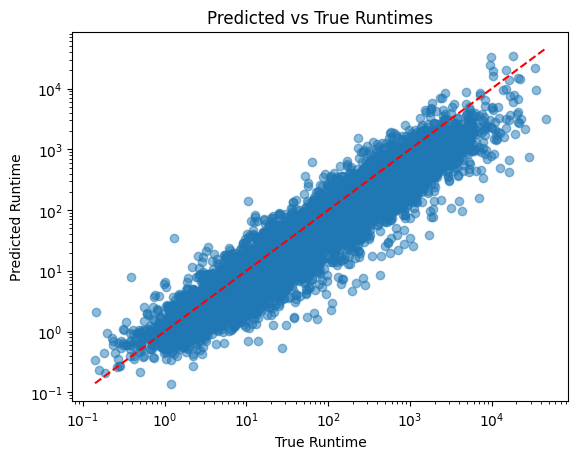

In [13]:
# Plot predicted vs actual runtimes
plot_pred(model, data_loader)

## Plot Prediction Error Distribution

## Performance for Different Input Scales

# GAT Eval

In [14]:
DIM_EMBEDDING = 64
gat = PipeGAT(hidden_channels=DIM_EMBEDDING, out_channels=DIM_EMBEDDING, num_layers=4, heads=8)
gat = to_hetero(gat, data.metadata(), aggr="sum")
model = PipelineModel(gat, DIM_EMBEDDING, 5, len(dataset.ast_vocab), len(dataset.sched_vocab))
model.load_state_dict(torch.load(GAT_MODEL_PATH, map_location=device))
model = model.to(device)

/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_1' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_2' with keyword argument 'traini

## Avergate Runtime Error

In [15]:
print(f"Average Runtime Error on Test Set: {average_runtime_error(model, data_loader) * 100:.2f}%")

Average Runtime Error on Test Set: 45.95%


## Prediction / True Runtime

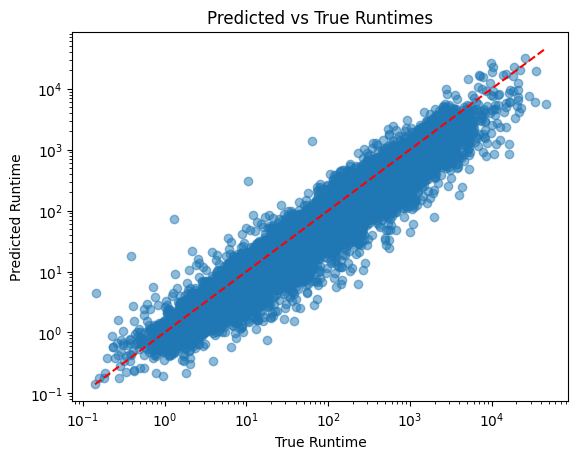

In [16]:
# Plot predicted vs actual runtimes
plot_pred(model, data_loader)

# Graph Transformer

In [17]:
vocab_size = get_ast_vocab_size() + get_sched_vocab_size() + 1
model = PipeGPS(
    hidden_channels=128,
    num_layers=8,
    num_attn_heads=8,
    attn_type="multihead",
    attn_kwargs={"dropout": 0.5},
    vocab_size=vocab_size,
    num_runtime_targets=5,
)
model.load_state_dict(torch.load(GRAPH_TRANSFORMER_MODEL_PATH, map_location=device))
model = model.to(device)

1lines [00:00, 9664.29lines/s]
1lines [00:00, 12787.51lines/s]


In [18]:
DIM_EMBEDDING = 64
gat = PipeGAT(hidden_channels=DIM_EMBEDDING, out_channels=DIM_EMBEDDING, num_layers=4, heads=8)
gat = to_hetero(gat, data.metadata(), aggr="sum")
model = PipelineModel(gat, DIM_EMBEDDING, 5, len(dataset.ast_vocab), len(dataset.sched_vocab))
model.load_state_dict(torch.load(GAT_MODEL_PATH, map_location=device))
model = model.to(device)

/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_1' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_2' with keyword argument 'traini

## Avergate Runtime Error

In [19]:
print(f"Average Runtime Error on Test Set: {average_runtime_error_transformer(model, data_loader_transformer) * 100:.2f}%")

TypeError: PipelineModel.forward() takes from 2 to 3 positional arguments but 6 were given

## Prediction / True Runtime

In [ ]:
# Plot predicted vs actual runtimes
plot_pred_transformer(model, data_loader_transformer)